# Imports


In [ ]:
import os
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import random
import plotly.express as px
import scipy as sp

from scipy import ndimage
from shutil import copyfile
from tensorflow.keras.layers import Conv2D,Add,MaxPooling2D, Dense, BatchNormalization,Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import scipy

# Directorios del Dataset

El dataset de rayos X ya viene organizado en carpetas train, test y val con las subcarpetas NORMAL y PNEUMONIA.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
import os

source_dir = '/content/drive/MyDrive/X-ray'
dest_dir = 'X-ray'


if os.path.exists(dest_dir):
    shutil.rmtree(dest_dir)


shutil.copytree(source_dir, dest_dir)
print(f"Successfully copied '{source_dir}' to '{dest_dir}'")

Successfully copied '/content/drive/MyDrive/X-ray' to 'X-ray'


In [ ]:
BASE_DIR = 'X-ray'


TRAINING_DIR = os.path.join(BASE_DIR, "train")
VALIDATION_DIR = os.path.join(BASE_DIR, "val")
TEST_DIR = os.path.join(BASE_DIR, "test")

TRAINING_NORMAL = os.path.join(TRAINING_DIR, "NORMAL")
TRAINING_PNEUMONIA = os.path.join(TRAINING_DIR, "PNEUMONIA")

VALIDATION_NORMAL = os.path.join(VALIDATION_DIR, "NORMAL")
VALIDATION_PNEUMONIA = os.path.join(VALIDATION_DIR, "PNEUMONIA")

TEST_NORMAL = os.path.join(TEST_DIR, "NORMAL")
TEST_PNEUMONIA = os.path.join(TEST_DIR, "PNEUMONIA")


INCLUDE_TEST = True

In [ ]:
print(len(os.listdir(TRAINING_NORMAL)))
print(len(os.listdir(TRAINING_PNEUMONIA)))
print(len(os.listdir(VALIDATION_NORMAL)))
print(len(os.listdir(VALIDATION_PNEUMONIA)))
print(len(os.listdir(TEST_NORMAL)))
print(len(os.listdir(TEST_PNEUMONIA)))

1341
3875
8
8
234
390


In [ ]:
class_names = ['Normal', 'Pneumonia']

n_normal = len(os.listdir('X-ray/train/NORMAL'))
n_pneumonia = len(os.listdir('X-ray/train/PNEUMONIA'))
n_images = [n_normal, n_pneumonia]
px.pie(names=class_names, values=n_images)

# Exploración del Dataset

In [ ]:
train_normal = len(os.listdir(TRAINING_NORMAL))
train_pneumonia = len(os.listdir(TRAINING_PNEUMONIA))

val_normal = len(os.listdir(VALIDATION_NORMAL))
val_pneumonia = len(os.listdir(VALIDATION_PNEUMONIA))

test_normal = len(os.listdir(TEST_NORMAL))
test_pneumonia = len(os.listdir(TEST_PNEUMONIA))

total_train = train_normal + train_pneumonia
total_val = val_normal + val_pneumonia
total_test = test_normal + test_pneumonia
total_all = total_train + total_val + total_test


print(f"Training Normal: {train_normal} imágenes")
print(f"Training Pneumonia: {train_pneumonia} imágenes")
print(f"Total Training: {total_train} imágenes ({(total_train/total_all)*100:.2f}%)\n")

print(f"Validation Normal: {val_normal} imágenes")
print(f"Validation Pneumonia: {val_pneumonia} imágenes")
print(f"Total Validation: {total_val} imágenes ({(total_val/total_all)*100:.2f}%)\n")

print(f"Test Normal: {test_normal} imágenes")
print(f"Test Pneumonia: {test_pneumonia} imágenes")
print(f"Total Test: {total_test} imágenes ({(total_test/total_all)*100:.2f}%)\n")

print(f"Total Imágenes: {total_all}")

Training Normal: 1341 imágenes
Training Pneumonia: 3875 imágenes
Total Training: 5216 imágenes (89.07%)

Validation Normal: 8 imágenes
Validation Pneumonia: 8 imágenes
Total Validation: 16 imágenes (0.27%)

Test Normal: 234 imágenes
Test Pneumonia: 390 imágenes
Total Test: 624 imágenes (10.66%)

Total Imágenes: 5856


# Generadores de Datos

In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255)

validation_gen = ImageDataGenerator(
    rescale=1./255.)

if INCLUDE_TEST:
    test_gen = ImageDataGenerator(
        rescale=1./255.)

In [ ]:
train_generator = train_gen.flow_from_directory(
    TRAINING_DIR,
    target_size=(150, 150),
    batch_size=64,
    class_mode='binary'
)

validation_generator = validation_gen.flow_from_directory(
    VALIDATION_DIR,
    target_size=(150, 150),
    batch_size=64,
    class_mode='binary'
)


if INCLUDE_TEST:
    test_generator = test_gen.flow_from_directory(
        TEST_DIR,
        target_size=(150, 150),
        batch_size=64,
        class_mode='binary'
    )

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


# Visualización de Imágenes

In [ ]:
def plot_data(generator, n_images):

    i = 1

    images, labels = next(generator)

    labels = labels.astype('int32')

    plt.figure(figsize=(14, 15))

    for image, label in zip(images, labels):
        plt.subplot(4, 3, i)
        plt.imshow(image)
        plt.title(class_names[label])
        plt.axis('off')
        i += 1
        if i == n_images:
            break

    plt.show()

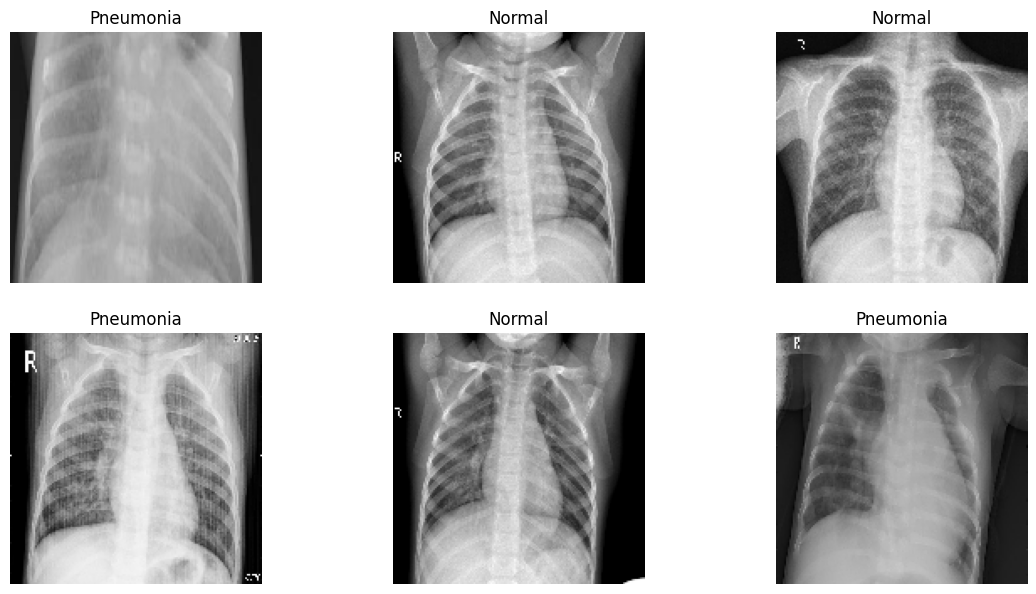

In [ ]:
plot_data(train_generator,7)

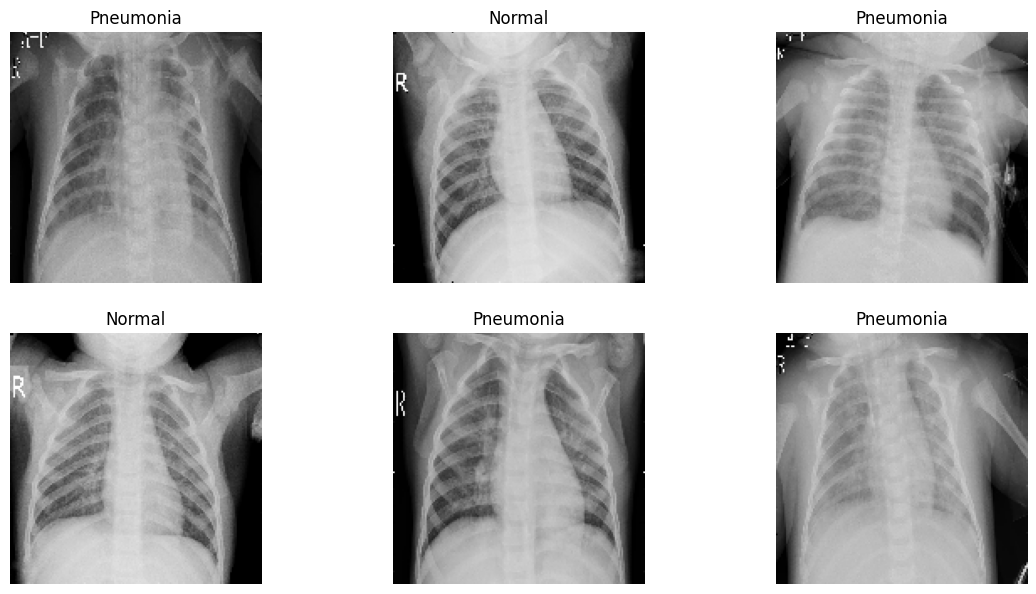

In [ ]:
plot_data(validation_generator,7)

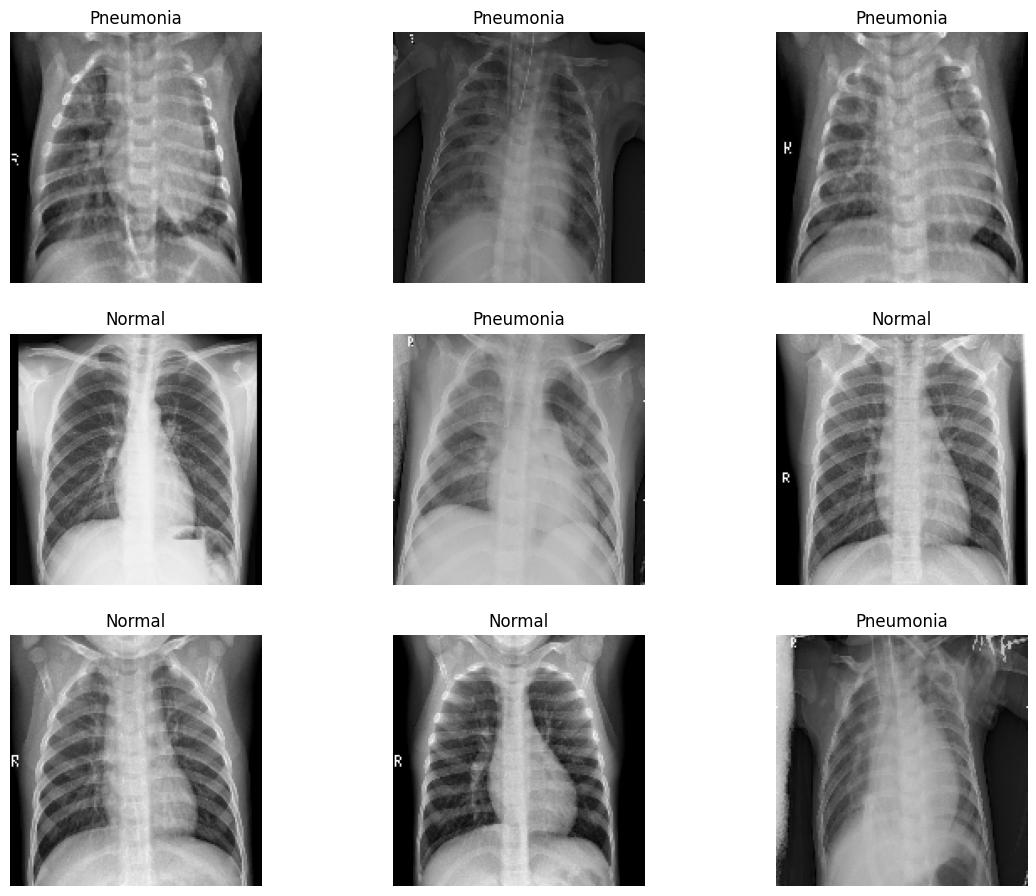

In [ ]:
if INCLUDE_TEST:
    plot_data(test_generator, 10)

# Construcción del Modelo

In [ ]:

inputs = tf.keras.layers.Input(shape=(150,150,3))
x = tf.keras.layers.Conv2D(32, (3,3), activation='relu')(inputs)
x = tf.keras.layers.Conv2D(64, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(2,2)(x)

x = tf.keras.layers.Conv2D(64, (3,3), activation='relu')(x)
x = tf.keras.layers.Conv2D(128, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(2,2)(x)

x = tf.keras.layers.Conv2D(128, (3,3), activation='relu')(x)
x = tf.keras.layers.Conv2D(256, (3,3), activation='relu')(x)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = Dense(1024, activation='relu')(x)

x = tf.keras.layers.Dense(2, activation='softmax')(x)

model = Model(inputs=inputs, outputs=x)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0005),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

# Entrenamiento del Modelo

In [ ]:

r = model.fit(
        train_generator,
        epochs=15,
        validation_data=validation_generator
)

Epoch 1/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 78s 748ms/step - accuracy: 0.7360 - loss: 0.5872 - val_accuracy: 0.5000 - val_loss: 0.8252
Epoch 2/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 53s 638ms/step - accuracy: 0.7429 - loss: 0.5730 - val_accuracy: 0.5000 - val_loss: 0.7652
Epoch 3/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 52s 639ms/step - accuracy: 0.7433 - loss: 0.5522 - val_accuracy: 0.5625 - val_loss: 0.7369
Epoch 4/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 82s 639ms/step - accuracy: 0.7559 - loss: 0.4723 - val_accuracy: 0.5625 - val_loss: 1.1619
Epoch 5/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 53s 644ms/step - accuracy: 0.8106 - loss: 0.3970 - val_accuracy: 0.6250 - val_loss: 0.7636
Epoch 6/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 52s 635ms/step - accuracy: 0.8217 - loss: 0.3610 - val_accuracy: 0.7500 - val_loss: 0.5844
Epoch 7/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 51s 618ms/step - accuracy: 0.8340 - loss: 0.3354 - val_accuracy: 0.6250 - val_loss: 0.8204
Epoch 8/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 53s 644ms/step - accuracy: 0.8367 - loss: 0.3267 - val_accu

# Evaluación en Test Set

In [53]:
if INCLUDE_TEST:
    model.evaluate(test_generator)

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 421ms/step - accuracy: 0.7388 - loss: 0.5505


# Predicciones y Visualización

In [54]:
def plot_prediction(generator, n_images):

    i = 1

    images, labels = next(generator)

    preds = model.predict(images)

    predictions = np.argmax(preds, axis=1)

    labels = labels.astype('int32')

    plt.figure(figsize=(14, 15))

    for image, label in zip(images, labels):
        plt.subplot(4, 3, i)
        plt.imshow(image)

        if predictions[i-1] == labels[i-1]:
            title_obj = plt.title(class_names[label])
            plt.setp(title_obj, color='g')
            plt.axis('off')
        else:
            title_obj = plt.title(class_names[label])
            plt.setp(title_obj, color='r')
            plt.axis('off')

        i += 1

        if i > n_images:
            break

    plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step


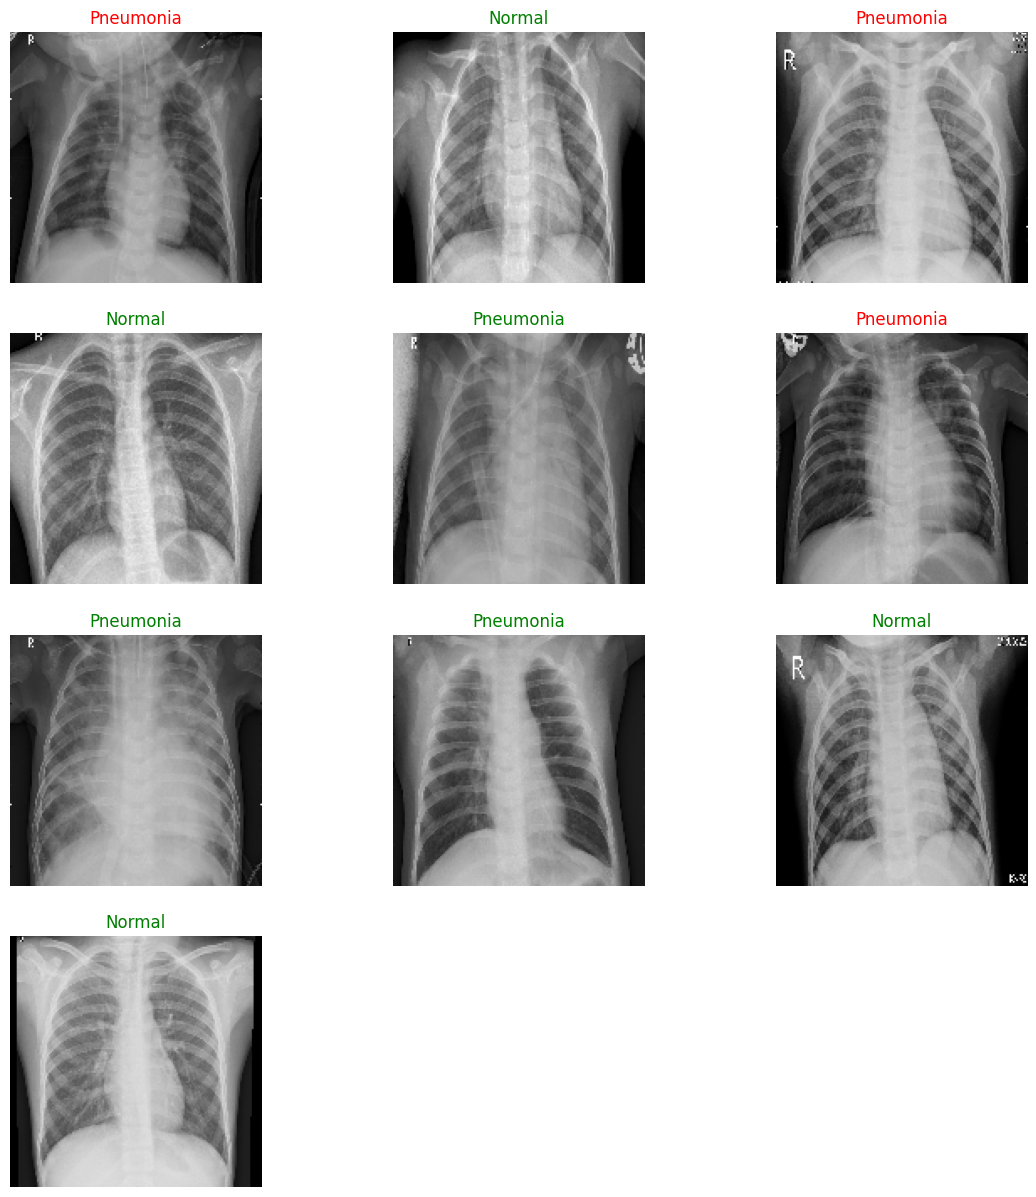

In [ ]:
if INCLUDE_TEST:
    plot_prediction(test_generator, 10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step


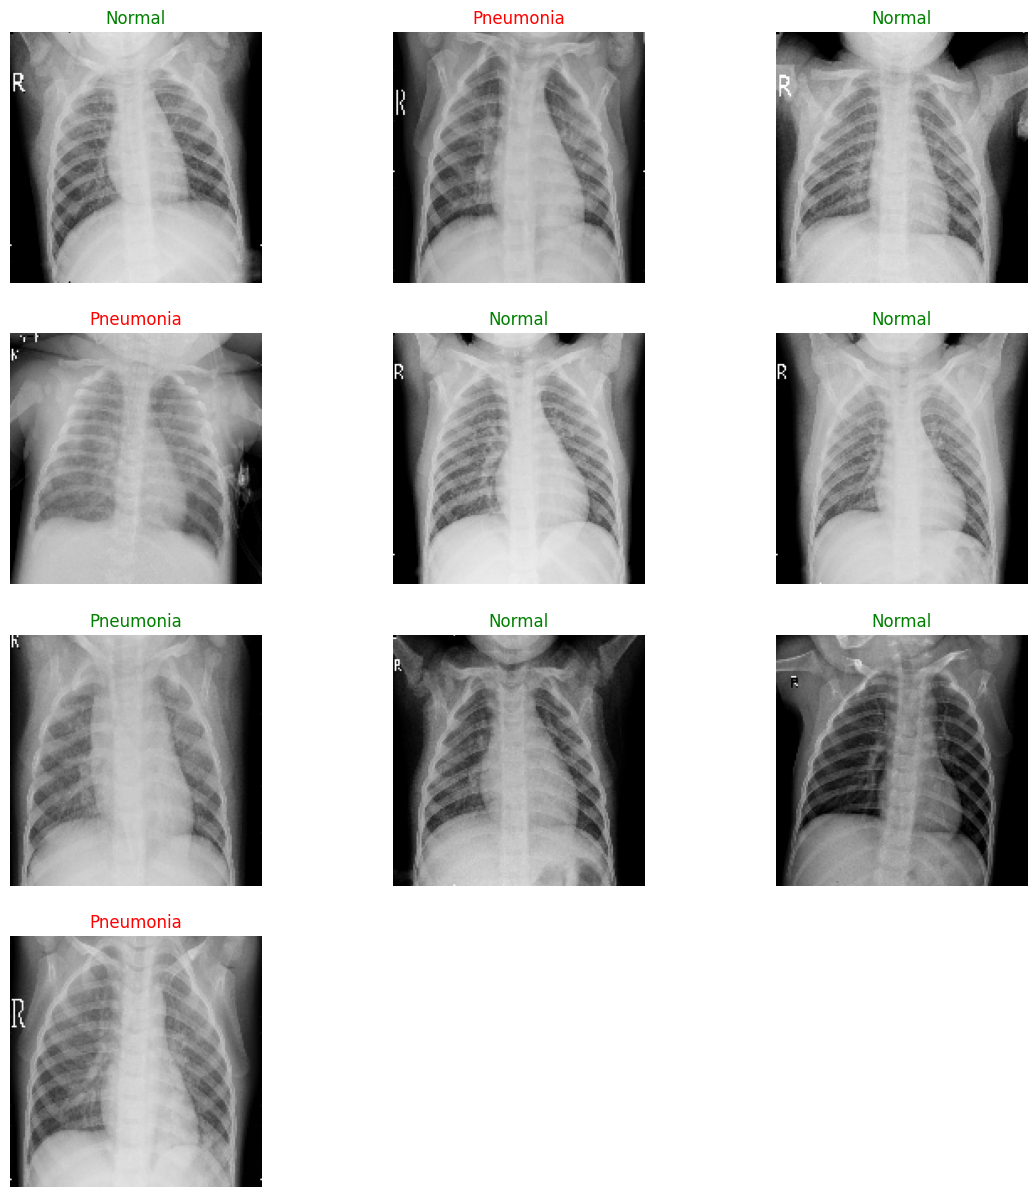

In [ ]:
plot_prediction(validation_generator, 10)

# Mapas de Activación de Clase (CAM)

In [55]:
gp_weights_dense_intermediate = model.get_layer('dense').get_weights()[0]
gp_weights_dense_final = model.get_layer('dense_1').get_weights()[0]

activation_model = Model(model.inputs, outputs=(model.get_layer('conv2d_5').output, model.get_layer('dense_1').output))

In [56]:
images, _ = next(test_generator)
features, results = activation_model.predict(images)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step 


In [69]:
def show_cam(image_index, features, results, cmap=None):

    features_for_img = features[image_index,:,:,:]

    prediction = np.argmax(results[image_index])

    effective_cam_weights = np.dot(gp_weights_dense_intermediate, gp_weights_dense_final[:, prediction])

    class_activation_features = sp.ndimage.zoom(features_for_img, (150/30, 150/30, 1), order=2)

    cam_output  = np.dot(class_activation_features, effective_cam_weights)

    print('Predicted Class = ' + str(class_names[prediction]) + ', Probability = ' + str(results[image_index][prediction]))

    plt.imshow(images[image_index])

    if cmap is None:
        if results[image_index][prediction] > 0.7:
            cmap_str = 'Jet'
        else:
            cmap_str = 'Blues'
    else:
        cmap_str = cmap

    plt.imshow(cam_output, cmap=cmap_str, alpha=0.5)

    plt.show()

In [63]:
def show_maps(desired_class, num_maps):

    counter = 0
    for i in range(0, len(features)):
        if counter == num_maps:
            break

        if np.argmax(results[i]) == desired_class:
            counter += 1
            show_cam(i, features, results)

Predicted Class = Pneumonia, Probability = 0.7385687


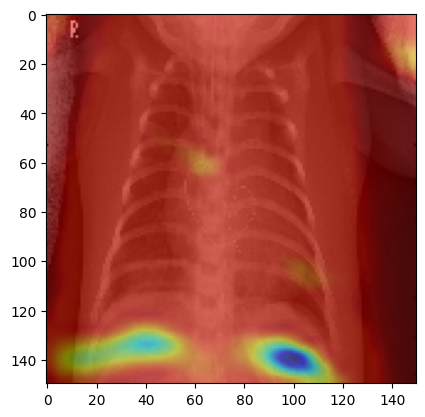

Predicted Class = Pneumonia, Probability = 0.6917888


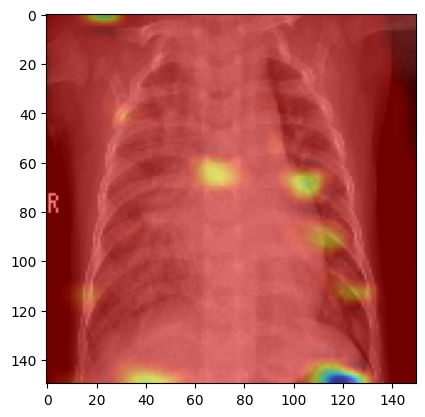

Predicted Class = Pneumonia, Probability = 0.79499376


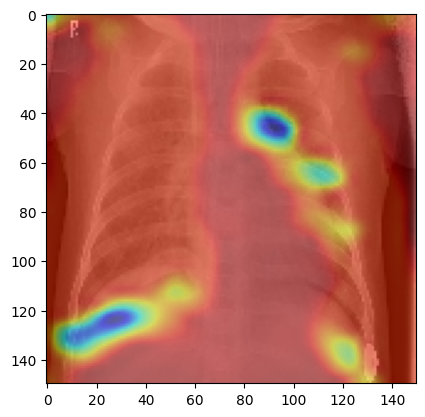

Predicted Class = Pneumonia, Probability = 0.9583017


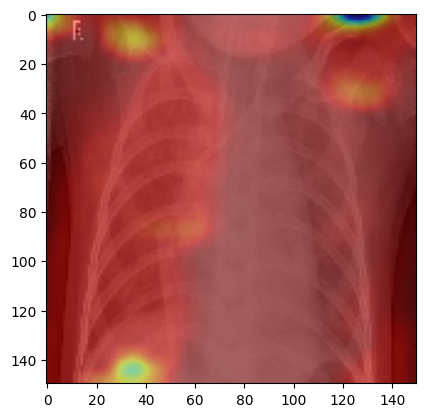

Predicted Class = Pneumonia, Probability = 0.9277464


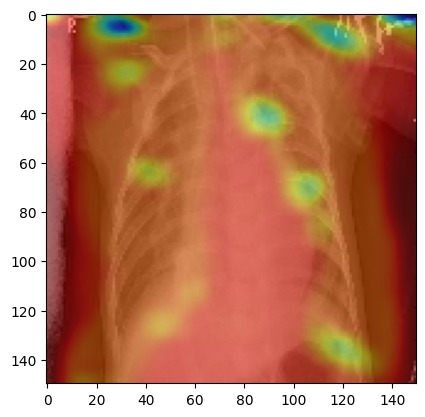

In [67]:
show_maps(desired_class=1, num_maps=5)

Predicted Class = Normal, Probability = 0.6752221


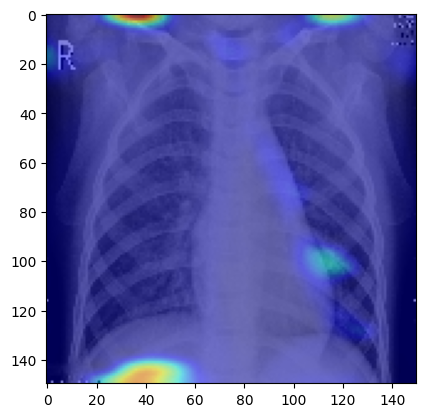

Predicted Class = Normal, Probability = 0.72309893


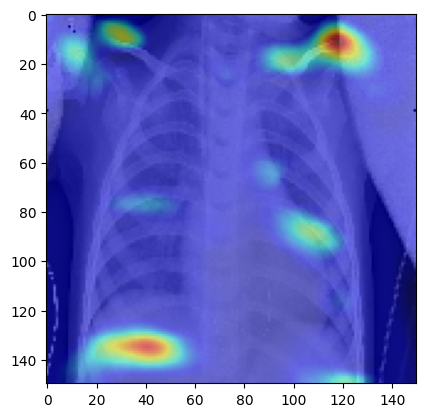

Predicted Class = Normal, Probability = 0.714359


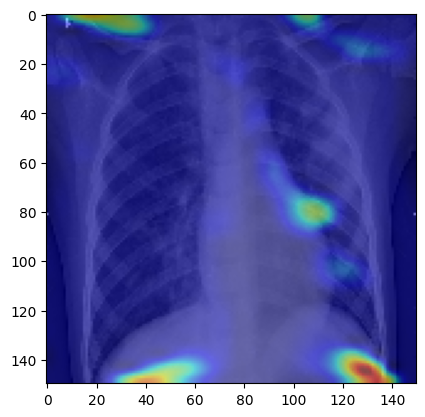

Predicted Class = Normal, Probability = 0.66749585


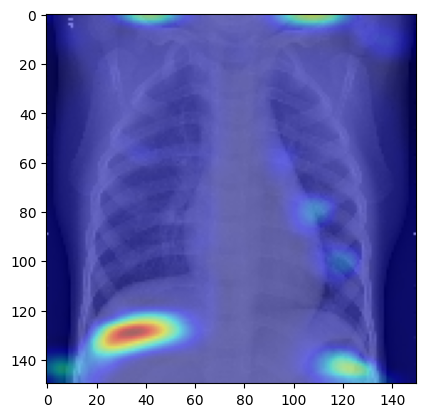

Predicted Class = Normal, Probability = 0.8031092


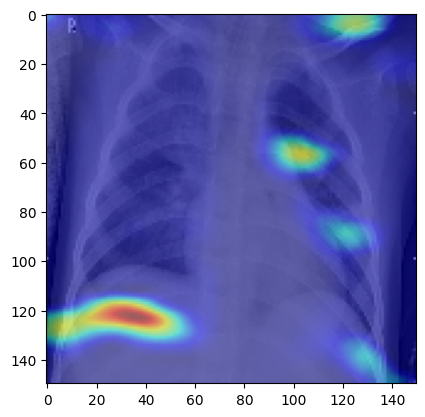

In [68]:
show_maps(desired_class=0, num_maps=5)

# Análisis de Resultados

In [ ]:
results = pd.DataFrame(r.history)
results.tail()

,accuracy,loss,val_accuracy,val_loss
10,0.869248,0.286241,0.8125,0.528944
11,0.886695,0.261680,0.8125,0.455782
12,0.888420,0.259997,0.6875,0.991110
13,0.892446,0.245667,0.6250,1.077804
14,0.903949,0.224909,0.6875,0.653841


In [ ]:
fig = px.line(results,y=[results['accuracy'],results['val_accuracy']],template="seaborn",color_discrete_sequence=['#fad25a','red'])
fig.update_layout(
    title_font_color="#fad25a",
    xaxis=dict(color="#fad25a",title='Epochs'),
    yaxis=dict(color="#fad25a")
 )
fig.show()

In [ ]:
fig = px.line(results,y=[results['loss'],results['val_loss']],template="seaborn",color_discrete_sequence=['#fad25a','red'])
fig.update_layout(
    title_font_color="#fad25a",
    xaxis=dict(color="#fad25a",title='Epochs'),
    yaxis=dict(color="#fad25a")
 )
fig.show()

# Data Augmentation

In [ ]:
train_gen_aug = ImageDataGenerator(
        rescale=1./255,fill_mode='nearest',horizontal_flip=True,
        rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
)


validation_gen_aug =  ImageDataGenerator(
        rescale=1./255.)

In [ ]:
train_generator = train_gen_aug.flow_from_directory(
        TRAINING_DIR,
        target_size=(150, 150),
        batch_size=32,
        class_mode='binary')
validation_generator = validation_gen_aug.flow_from_directory(
        VALIDATION_DIR,
        target_size=(150, 150),
        batch_size=32,
        class_mode='binary')

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [ ]:
inputs = tf.keras.layers.Input(shape=(150,150,3))
x =  tf.keras.layers.Conv2D(32, (3,3), activation='relu')(inputs)
x = tf.keras.layers.Conv2D(64, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(2,2)(x)

x = tf.keras.layers.Conv2D(64, (3,3), activation='relu')(x)
x = tf.keras.layers.Conv2D(128, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(2,2)(x)

x = tf.keras.layers.Conv2D(128, (3,3), activation='relu')(x)
x = tf.keras.layers.Conv2D(256, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(2,2)(x)

x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(1024, activation='relu')(x)
x = tf.keras.layers.Dense(2, activation='softmax')(x)

model_aug = Model(inputs=inputs, outputs=x)

In [ ]:
model_aug.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0005),
              loss='sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [ ]:
r = model_aug.fit(
        train_generator,
        epochs=15,
        validation_data=validation_generator)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 88s 516ms/step - accuracy: 0.7333 - loss: 0.6036 - val_accuracy: 0.5000 - val_loss: 0.7913
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 507ms/step - accuracy: 0.7544 - loss: 0.4894 - val_accuracy: 0.6250 - val_loss: 0.6420
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 142s 504ms/step - accuracy: 0.8183 - loss: 0.3729 - val_accuracy: 0.6875 - val_loss: 0.8886
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 82s 503ms/step - accuracy: 0.8635 - loss: 0.2906 - val_accuracy: 0.6875 - val_loss: 0.8060
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 82s 504ms/step - accuracy: 0.8792 - loss: 0.2711 - val_accuracy: 0.7500 - val_loss: 0.6368
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 82s 504ms/step - accuracy: 0.8886 - loss: 0.2498 - val_accuracy: 0.6875 - val_loss: 0.8716
Epoch 7/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 511ms/step - accuracy: 0.9018 - loss: 0.2339 - val_accuracy: 0.6875 - val_loss: 1.0477
Epoch 8/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 81s 500ms/step - accuracy: 0.9055 - loss: 

In [39]:
if INCLUDE_TEST:
    model_aug.evaluate(test_generator)

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 525ms/step - accuracy: 0.8077 - loss: 0.4610


In [40]:
results = pd.DataFrame(r.history)
results.tail()

,accuracy,loss,val_accuracy,val_loss
10,0.924847,0.192641,0.5000,1.373159
11,0.923888,0.187670,0.6875,0.682040
12,0.930790,0.168795,0.6875,0.572377
13,0.935966,0.162108,0.6875,0.645683
14,0.937117,0.158060,0.6875,0.675842


In [41]:
fig = px.line(results,y=[results['accuracy'],results['val_accuracy']],template="seaborn",color_discrete_sequence=['#fad25a','red'])
fig.update_layout(
    title_font_color="#fad25a",
    xaxis=dict(color="#fad25a",title='Epochs'),
    yaxis=dict(color="#fad25a")
 )
fig.show()

In [42]:
fig = px.line(results,y=[results['loss'],results['val_loss']],template="seaborn",color_discrete_sequence=['#fad25a','red'])
fig.update_layout(
    title_font_color="#fad25a",
    xaxis=dict(color="#fad25a",title='Epochs'),
    yaxis=dict(color="#fad25a")
 )
fig.show()